In [ ]:
#[데이터 결측치 제거 (빠지거나 누락된 데이터)]
import pandas as pd
df_nomiss = pd.dropna() # 모든 결측치 제거
df_nomiss = pd.dropna(subset=['score']) # score열에 있는 결측치만 제거

#[결측치를 대체할수있다]
exam = pd.read_csv('exam.csv')
ex_mean = exam['math'].mean()
exam['math] = exam['math'].fillna(ex_mean) #누락된 데이터를 평균값 55로 채운다

In [17]:
# 극단치 기준값을 구한후, seaborn으로 그래프를 그린다
import pandas as pd
import seaborn as sns
import numpy as np

mpg = pd.read_csv('mpg.csv')

pct25 = mpg['hwy'].quantile(.25)
pct50 = mpg['hwy'].quantile(.50)
pct75 = mpg['hwy'].quantile(.75)
iqr = pct75 - pct25
minimum = pct25 -(iqr * 1.5 )
maximum = pct75 + (iqr * 1.5)

print(f"mpg['hwy]의 하한 : {minimum}")
print(f"mpg['hwy']의 1분위수 : {pct25}")
print(f"mpg['hwy']의 2분위수 : {pct50}")
print(f"mpg['hwy']의 3분위수 : {pct75}")
print(f"mpg['hwy]의 상한 : {maximum}")

#sns.boxplot(data=mpg, x='hwy')

# 3.극단치를 결측처리하기
mpg['hwy'] = np.where( (mpg['hwy'] < 4.5) | (mpg['hwy'] > 40.5 ), np.nan, mpg['hwy'] )
#mpg['hwy'].isna().sum()

#mpg.groupby('drv').agg(mean_hwy=('hwy','mean'))
#4. 결측치를 제거하고 분석하기
mpg.dropna(subset=['hwy']).groupby('drv').agg(mean_hwy=('hwy','mean'))

mpg['hwy]의 하한 : 4.5
mpg['hwy']의 1분위수 : 18.0
mpg['hwy']의 2분위수 : 24.0
mpg['hwy']의 3분위수 : 27.0
mpg['hwy]의 상한 : 40.5


,mean_hwy
drv,
4,19.174757
f,27.728155
r,21.000000


<Axes: ylabel='cty'>

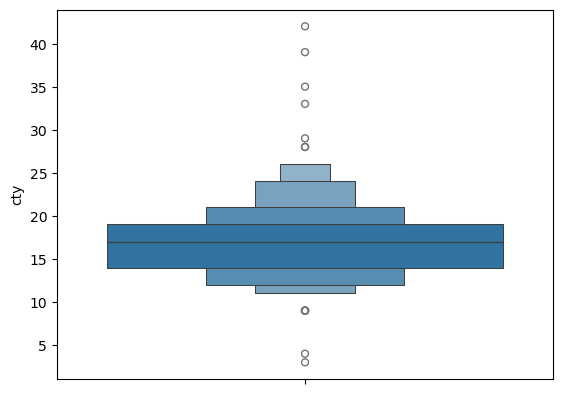

In [ ]:
# p.194 혼자서 해보기
import pandas as pd
import numpy as np
import seaborn as sns

mpg = pd.read_csv('mpg.csv')
mpg.loc[[9,13,57,92],'drv'] = 'k'
mpg.loc[[28,42,128,202],'cty'] = [3,4,39,42]


# 1. drv에 이상치가 있는지 확인한다. 결측처리한 후 이상치가 사라졌는지 확인한다
# mpg['drv'] = np.where( mpg['drv'].isin(['4','f','r']), mpg['drv'],np.nan)
# #mpg['drv'].isna().sum()
# mpg.dropna(subset=['drv']).isna().sum()

# 2. cty에 이상이 있는지 확인. 
# 상자그림 기준으로 정상을 벗어난값을 결측처리후, 다시 상자그림을 만들어 이상치가 사라졌는지확인
pct25 = mpg['cty'].quantile(.25)
pct75 = mpg['cty'].quantile(.75)
iqr = pct75 - pct25
maximum = pct75 + (iqr*1.5)
minimum = pct25 - (iqr*1.5)

mpg['cty'] = np.where((mpg['cty'] > maximum) | (mpg['cty'] <)
sns.boxenplot(data=mpg, y='cty')


# 3. 두변수의 이상치를 제거한다음 drv별로 cty평균이 어떻게 다른지 확인해본다. 하나의 pandas구문으로
